In [1]:

import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
#from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

**Data Generation**

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [4]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=6):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

**Import related package for NN**

In [5]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math

In [6]:
# ===== Architecture of Prospective MLP =====
class TorchMLP(nn.Module):
    def __init__(self, in_dim=57):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.out(x).squeeze(-1)
        return x


# ===== Trainer =====
class TorchMLPTrainer:
    def __init__(self, in_dim, lr_group=(3e-3, 1e-2, 1e-2), weight_decay=1e-4, device=None, seed=42):
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = device
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # Initialize Model
        self.model = TorchMLP(in_dim=in_dim).to(self.device)

        # Layer_wise Learning rate
        self.optimizer = optim.Adam(
            [
                {"params": self.model.fc1.parameters(), "lr": lr_group[0]},
                {"params": self.model.fc2.parameters(), "lr": lr_group[1]},
                {"params": self.model.out.parameters(), "lr": lr_group[2]},
            ],
            weight_decay=weight_decay,
        )

        self.loss_fn = nn.MSELoss()

    def partial_fit(self, X_np, y_np, epochs=50, batch_size=32):
        X = torch.from_numpy(X_np).float().to(self.device)
        y = torch.from_numpy(y_np).float().to(self.device)
        ds = TensorDataset(X, y)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

        self.model.train()
        for _ in range(epochs):
            for xb, yb in dl:
                pred = self.model(xb)
                loss = self.loss_fn(pred, yb)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

    @torch.no_grad()
    def predict(self, X_np):
        self.model.eval()
        X = torch.from_numpy(X_np).float().to(self.device)
        return self.model(X).detach().cpu().numpy()

**Proforg_NN**

128 training done (epochs=200)
226.52947834139022
100.16923224017675
Pregret: 1.2636024610121346


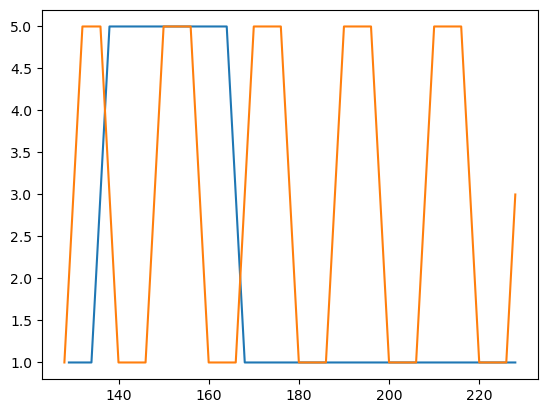

256 training done (epochs=316)
242.07326268668774
120.88399419249362
Pregret: 1.2118926849419411


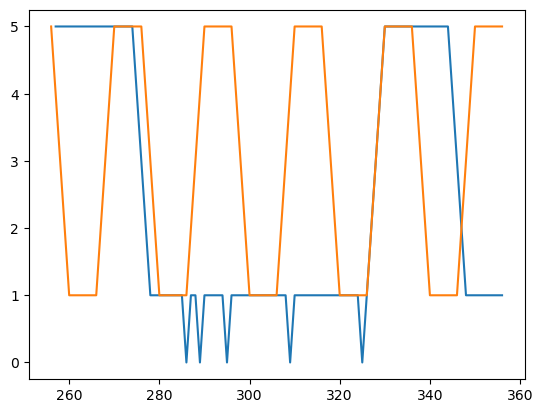

512 training done (epochs=464)
244.2386545823021
114.02095681787846
Pregret: 1.3021769776442362


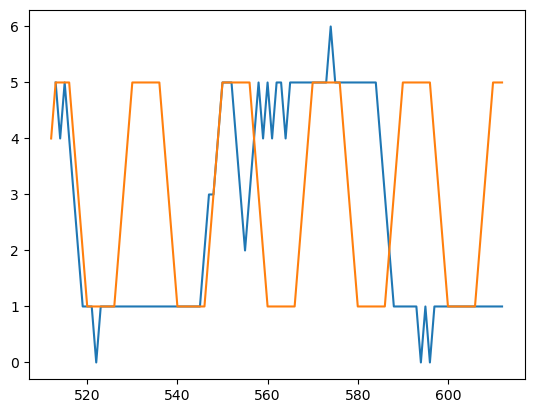

750 training done (epochs=555)
240.51798883886897
146.61490065551297
Pregret: 0.9390308818335601


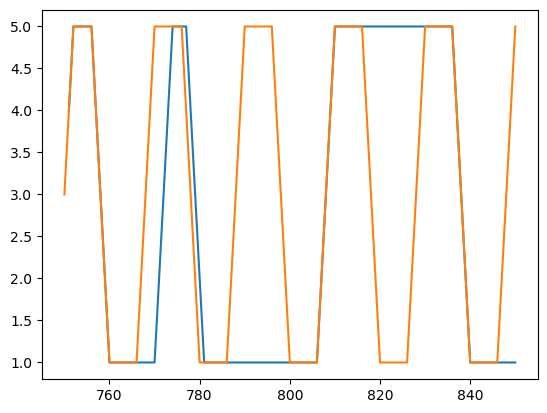

1024 training done (epochs=633)
243.60850098328572
167.9371738300297
Pregret: 0.7567132715325602


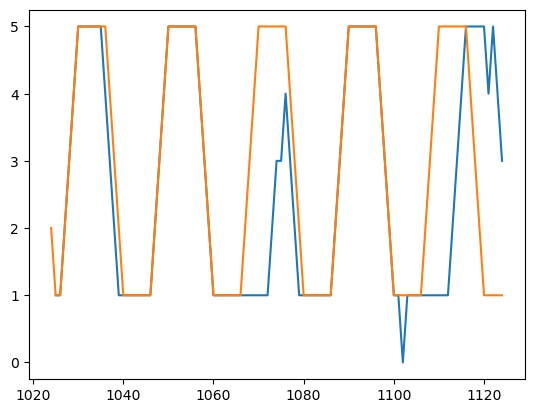

1250 training done (epochs=685)
240.51798883886897
193.94810643283745
Pregret: 0.46569882406031526


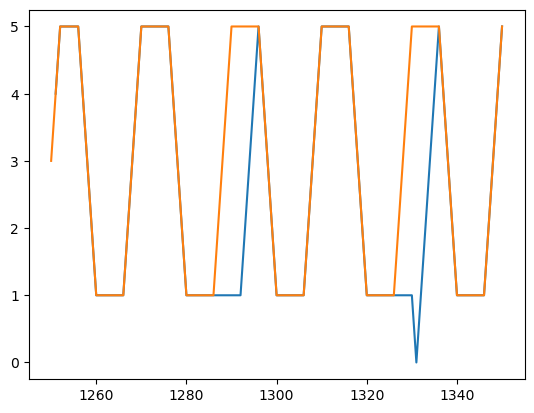

1500 training done (epochs=733)
237.09798883886901
237.09798883886901
Pregret: 0.0


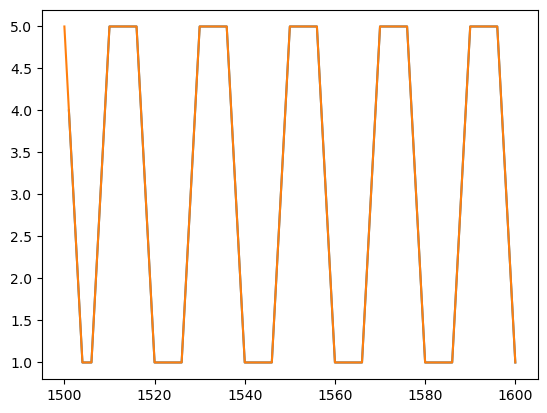

2048 training done (epochs=817)
236.02947834139022
236.02947834139022
Pregret: 0.0


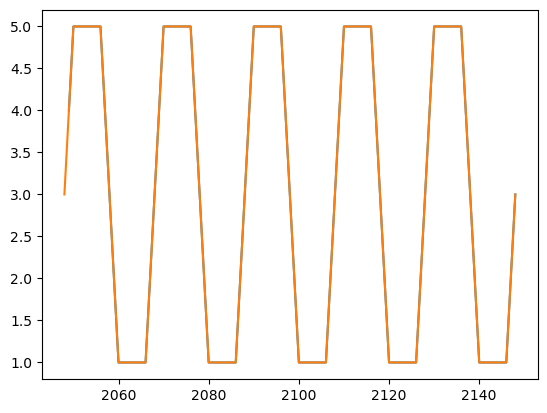

In [8]:
gamma = 0.5
Ts = [128,256,512,750,1024,1250,1500,2048]

T0 = 128          # Min Time
base_epoch = 200  # Min Epoch

for rep in range(1):
    for t_prime in [6]:
        FUTURE_STATE = []
        actions, states, irewards, times = simulate_data_raw(
            rewards_in_period = rewards_in_period,
            session_duration = 500000,
            tdim=50,
            n_sessions=1,
            seed  = 515 + rep
        )

        state_posencode_oh = position_encoder(states[:,0], type="onehot")
        new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

        trainer = TorchMLPTrainer(in_dim=new_state_oh.shape[1])

        for T in Ts:
            X_train = new_state_oh[:T,:]
            Y_train = irewards[:T]

            # Dynamic number of epochs
            epochs = int(base_epoch * math.log2(T / T0 + 1))
            trainer.partial_fit(X_train, Y_train, epochs=epochs)
            print(f"{T} training done (epochs={epochs})")

            current_state = states[T,0]
            future_states = [current_state]

            for delta_t in range(100):
                df_all_paths = enumerate_paths(
                    x0=current_state,
                    t_inital = T+delta_t,
                    t_prime=t_prime
                )
                n_paths = df_all_paths.shape[0]
                irewards_pred = np.zeros((n_paths,  t_prime+1))

                for i in range(t_prime+1):
                    cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                    curr_time = T+1+delta_t+i
                    time_emb = time_embedding_np(
                        np.ones(cand_pe.shape[0])*curr_time,
                        tdim=50
                    )
                    features = np.hstack([cand_pe,time_emb])
                    irewards_pred[:,i] = trainer.predict(features)

                reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
                df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
                rewards_matrix = df_ireward.iloc[:, 1:].values
                discounts = gamma ** np.arange(1, t_prime+1)

                discounted_returns = rewards_matrix * discounts
                total_discounted = discounted_returns.sum(axis=1)
                bext_idx = np.argmax(total_discounted)
                next_state = int(df_all_paths.iloc[bext_idx,1])
                future_states.append(next_state)
                current_state = next_state

            FUTURE_STATE.append(future_states)

            irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
            preward = compute_normalized_future_rewards(irewards_test,100,0.5)
            path, ireward_opt = path_opt(future_states[0], T, 100)
            preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            print(np.sum(preward_opt_test))
            print(np.sum(preward))
            pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
            print("Pregret:", pregret)

            plt.plot(np.arange(T+1,T+101),future_states[1:])
            plt.plot(np.arange(T,T+101),path)
            plt.show()

        FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
        np.savez(
            f"../result_PAFM_revised/One_hot/NN_onehot_w_lookahead_reps{rep}.npz",
            future_states =FUTURE_STATE_arr
            )


In [10]:
#Oracle
gamma = 0.5
Ts = [128,256,512,750,1024,1250,1500,2048]

T0 = 128          # Min Time
base_epoch = 200  # Min Epoch
DELTA_t = 5
t_prime = 6
FUTURE_STATE = []
for T in Ts:
    n_seq = int(T/DELTA_t)
    # n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards,gamma = 0.5))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe)
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
    X_train = STATES_arr
    Y_train = REWARDS_arr
    epochs = int(base_epoch * math.log2(T / T0 + 1))
    trainer.partial_fit(X_train, Y_train, epochs=epochs)
    print(f"{T} training done (epochs={epochs})")

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = trainer.predict(features)
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
    
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"E:../result_PAFM/Oracle/NN_oracle_w_lookahead.npz",
    future_states =FUTURE_STATE_arr
    )

25
(150, 57) (150,)


KeyboardInterrupt: 